In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from imblearn.over_sampling import SMOTE
import pickle
import joblib

from  sklearn.pipeline import Pipeline


In [2]:
pd.set_option('display.max_columns', None)
df = pd.read_excel('../underwriting_50k_dataset.xlsx', sheet_name='Claims_Fraud_Detection')
df.head()

,claim_id,customer_id,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital_gains,capital_loss,credit_score,telematics_score,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,prior_claims_count,fraud_score,fraud_pattern,rule_flag,decline_reason,claim_outcome,submission_text,adjuster_notes,fraud_reported,policy_effective_date,policy_expiration_date,incident_in_policy_period,policy_status_at_incident,incident_near_boundary,is_complex_claim
0,CL-129460,CUST-93810,23,28,POL-651065,2021-06-29,PA,250/500,1000,1262.80,1000000,71927,FEMALE,JD,adm-clerical,exercise,wife,0,9272,496,22.1,2020-07-17,Single Vehicle Collision,Front Collision,Total Loss,Police,PA,North Judithbury,Residential Street,18,4,NO,1,1,?,16915,2884,3359,10672,Chevrolet,Equinox,2011,0,0.0249,NaN,NONE,Policy cancelled prior to loss,Closed – No Payment,"I need to file a claim. On 2020-07-17, I was i...",[2020-08-04] Liability assessment: Based on vi...,N,2021-06-29,2022-06-29,N,Not Yet Effective,N,Y
1,CL-248851,CUST-24592,260,30,POL-272752,2018-06-12,MA,250/500,250,1599.10,0,28722,FEMALE,Associate,handlers-cleaners,camping,not-in-family,0,0,682,50.8,2023-01-27,Single Vehicle Collision,Rear Collision,Minor Damage,NaN,MA,Robinsonshire,Highway,19,3,YES,3,0,YES,55961,284,11360,44317,Kia,Soul,2004,2,0.7113,Staged collision with known associate,PRIOR_CLAIMS,Coverage lapsed at incident date,Denied,Claim submission: Date of loss 2023-01-27. Typ...,[2023-02-23] Medical records received from Ort...,Y,2018-06-12,2019-06-12,N,Expired,N,Y
2,CL-350302,CUST-13278,321,59,POL-851728,2013-02-12,NJ,500/1000,1000,2783.56,0,50116,FEMALE,Bachelors,handlers-cleaners,skydiving,not-in-family,0,21182,685,98.6,2019-06-13,Vehicle Theft,Side Collision,Trivial Damage,Fire,NJ,Curtisfurt,Interstate,18,4,?,0,0,YES,22055,0,924,21131,Kia,Soul,2006,3,0.9183,Vehicle reported stolen but located nearby,PRIOR_CLAIMS,Incident date outside policy period,Denied,"Hi, I'd like to report a Vehicle Theft that oc...",[2019-06-27] Witness interview conducted with ...,Y,2013-02-12,2014-02-12,N,Expired,N,Y
3,CL-965465,CUST-22943,350,55,POL-662583,2012-06-17,NC,500/1000,1000,3111.41,0,27961,MALE,Masters,sales,yoga,husband,0,0,632,34.3,2022-12-06,Vehicle Theft,Rear Collision,Major Damage,Other,NC,New Kellystad,Interstate,9,1,NO,1,2,YES,13539,2513,2404,8622,Hyundai,Sonata,2007,2,0.0504,NaN,NONE,Policy cancelled prior to loss,Denied,"Filing auto claim – 2022-12-06, Vehicle Theft,...",[2022-12-07] Witness interview conducted with ...,N,2012-06-17,2013-06-17,N,Expired,N,Y
4,CL-324958,CUST-42098,112,49,POL-101688,2013-08-29,NY,500/1000,500,3782.20,100000,84387,FEMALE,High School,craft-repair,sleeping,not-in-family,0,0,474,66.4,2024-04-05,Multi-vehicle Collision,Side Collision,Minor Damage,Fire,NY,Jacquelineland,Residential Street,20,2,?,1,0,YES,57783,10918,10288,36577,Jeep,Cherokee,2021,4,0.8127,Inflated repair estimate submitted,SUSPICIOUS_HOUR,Policy cancelled prior to loss,Under Investigation,My car was in an accident on 2024-04-05. It ha...,[2024-05-04] Claimant submitted repair estimat...,Y,2013-08-29,2014-08-29,N,Expired,N,Y


In [3]:
df.shape

(50000, 57)

In [4]:
df.columns

Index(['claim_id', 'customer_id', 'months_as_customer', 'age', 'policy_number',
       'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital_gains', 'capital_loss', 'credit_score',
       'telematics_score', 'incident_date', 'incident_type', 'collision_type',
       'incident_severity', 'authorities_contacted', 'incident_state',
       'incident_city', 'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'prior_claims_count', 'fraud_score',
       'fraud_pattern', 'rule_flag', 'decline_reason', 'claim_outcome',
       'submission_text',

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 57 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   claim_id                     50000 non-null  str    
 1   customer_id                  50000 non-null  str    
 2   months_as_customer           50000 non-null  int64  
 3   age                          50000 non-null  int64  
 4   policy_number                50000 non-null  str    
 5   policy_bind_date             50000 non-null  str    
 6   policy_state                 50000 non-null  str    
 7   policy_csl                   50000 non-null  str    
 8   policy_deductable            50000 non-null  int64  
 9   policy_annual_premium        50000 non-null  float64
 10  umbrella_limit               50000 non-null  int64  
 11  insured_zip                  50000 non-null  int64  
 12  insured_sex                  50000 non-null  str    
 13  insured_education_level    

In [6]:
df.describe()

,months_as_customer,age,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital_gains,capital_loss,credit_score,telematics_score,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,prior_claims_count,fraud_score
count,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,180.899540,46.432080,934.775000,2555.872765,7.182380e+05,50241.38008,3764.44782,1395.422920,649.411600,59.982266,12.274540,2.495200,1.502840,1.055020,21382.102960,2792.493280,2681.873920,15907.735760,2013.475400,1.152920,0.333987
std,103.709329,16.676799,669.851419,1124.468528,7.320114e+05,28737.92210,11697.31109,4616.104006,115.364175,23.175207,6.087044,1.115689,1.117881,0.919179,20308.440181,4309.316981,3329.664129,15613.254127,5.768624,1.221313,0.291281
min,1.000000,18.000000,250.000000,600.070000,0.000000e+00,502.00000,0.00000,0.000000,450.000000,20.000000,0.000000,1.000000,0.000000,0.000000,300.000000,0.000000,0.000000,131.000000,2004.000000,0.000000,0.010000
25%,92.000000,32.000000,250.000000,1577.292500,1.000000e+05,25291.00000,0.00000,0.000000,550.000000,39.900000,8.000000,1.000000,1.000000,0.000000,8392.000000,0.000000,589.000000,5981.750000,2008.000000,0.000000,0.121000
50%,181.000000,46.000000,500.000000,2564.615000,5.000000e+05,50360.00000,0.00000,0.000000,648.000000,59.800000,12.000000,2.000000,2.000000,1.000000,15781.500000,1207.000000,1602.000000,11344.500000,2013.000000,1.000000,0.233050
75%,271.000000,61.000000,1000.000000,3530.292500,1.000000e+06,75163.50000,0.00000,0.000000,749.000000,80.100000,17.000000,3.000000,3.000000,2.000000,23283.000000,3655.250000,3341.000000,18151.500000,2018.000000,2.000000,0.345900
max,360.000000,75.000000,2000.000000,4499.980000,2.000000e+06,99950.00000,59982.00000,24979.000000,850.000000,100.000000,23.000000,4.000000,3.000000,3.000000,89993.000000,31171.000000,22327.000000,89269.000000,2023.000000,4.000000,0.990000


In [7]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

In [8]:
numerical_cols

['months_as_customer',
 'age',
 'policy_deductable',
 'policy_annual_premium',
 'umbrella_limit',
 'insured_zip',
 'capital_gains',
 'capital_loss',
 'credit_score',
 'telematics_score',
 'incident_hour_of_the_day',
 'number_of_vehicles_involved',
 'bodily_injuries',
 'witnesses',
 'total_claim_amount',
 'injury_claim',
 'property_claim',
 'vehicle_claim',
 'auto_year',
 'prior_claims_count',
 'fraud_score']

In [9]:
categorical_cols = df.select_dtypes(include=['str']).columns.tolist()

In [10]:
categorical_cols

['claim_id',
 'customer_id',
 'policy_number',
 'policy_bind_date',
 'policy_state',
 'policy_csl',
 'insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'insured_relationship',
 'incident_date',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_city',
 'incident_location',
 'property_damage',
 'police_report_available',
 'auto_make',
 'auto_model',
 'fraud_pattern',
 'rule_flag',
 'decline_reason',
 'claim_outcome',
 'submission_text',
 'adjuster_notes',
 'fraud_reported',
 'policy_effective_date',
 'policy_expiration_date',
 'incident_in_policy_period',
 'policy_status_at_incident',
 'incident_near_boundary',
 'is_complex_claim']

In [11]:
df.isnull().sum()

claim_id                           0
customer_id                        0
months_as_customer                 0
age                                0
policy_number                      0
policy_bind_date                   0
policy_state                       0
policy_csl                         0
policy_deductable                  0
policy_annual_premium              0
umbrella_limit                     0
insured_zip                        0
insured_sex                        0
insured_education_level            0
insured_occupation                 0
insured_hobbies                    0
insured_relationship               0
capital_gains                      0
capital_loss                       0
credit_score                       0
telematics_score                   0
incident_date                      0
incident_type                      0
collision_type                     0
incident_severity                  0
authorities_contacted           9847
incident_state                     0
i

In [12]:
FEATURE_COLUMNS = [
    'months_as_customer',
    'age',
    'insured_sex',
    'insured_education_level',
    'insured_occupation',
    'insured_hobbies',
    'insured_relationship',
    
    'policy_state',
    'policy_csl',
    'policy_deductable',
    'policy_annual_premium',
    'umbrella_limit',
    'capital_gains',
    'capital_loss',
    'credit_score',
    'telematics_score',
    'incident_type',
    'collision_type',
    'incident_severity',
    'authorities_contacted',
    'incident_state',
    'incident_location',
    'incident_hour_of_the_day',
    'number_of_vehicles_involved',
    'property_damage',
    'bodily_injuries',
    'witnesses',
    'police_report_available',
    'total_claim_amount',
    'prior_claims_count',
    'auto_make',
    'auto_year',
    'injury_claim',
    'property_claim',
    'vehicle_claim',
    'incident_in_policy_period',
    'policy_status_at_incident',
    'incident_near_boundary',
    'is_complex_claim',
]
TARGET_COLUMN = 'fraud_reported'
data = df[FEATURE_COLUMNS + [TARGET_COLUMN]]

In [13]:
data.head()

,months_as_customer,age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,capital_gains,capital_loss,credit_score,telematics_score,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,prior_claims_count,auto_make,auto_year,injury_claim,property_claim,vehicle_claim,incident_in_policy_period,policy_status_at_incident,incident_near_boundary,is_complex_claim,fraud_reported
0,23,28,FEMALE,JD,adm-clerical,exercise,wife,PA,250/500,1000,1262.80,1000000,0,9272,496,22.1,Single Vehicle Collision,Front Collision,Total Loss,Police,PA,Residential Street,18,4,NO,1,1,?,16915,0,Chevrolet,2011,2884,3359,10672,N,Not Yet Effective,N,Y,N
1,260,30,FEMALE,Associate,handlers-cleaners,camping,not-in-family,MA,250/500,250,1599.10,0,0,0,682,50.8,Single Vehicle Collision,Rear Collision,Minor Damage,NaN,MA,Highway,19,3,YES,3,0,YES,55961,2,Kia,2004,284,11360,44317,N,Expired,N,Y,Y
2,321,59,FEMALE,Bachelors,handlers-cleaners,skydiving,not-in-family,NJ,500/1000,1000,2783.56,0,0,21182,685,98.6,Vehicle Theft,Side Collision,Trivial Damage,Fire,NJ,Interstate,18,4,?,0,0,YES,22055,3,Kia,2006,0,924,21131,N,Expired,N,Y,Y
3,350,55,MALE,Masters,sales,yoga,husband,NC,500/1000,1000,3111.41,0,0,0,632,34.3,Vehicle Theft,Rear Collision,Major Damage,Other,NC,Interstate,9,1,NO,1,2,YES,13539,2,Hyundai,2007,2513,2404,8622,N,Expired,N,Y,N
4,112,49,FEMALE,High School,craft-repair,sleeping,not-in-family,NY,500/1000,500,3782.20,100000,0,0,474,66.4,Multi-vehicle Collision,Side Collision,Minor Damage,Fire,NY,Residential Street,20,2,?,1,0,YES,57783,4,Jeep,2021,10918,10288,36577,N,Expired,N,Y,Y


In [14]:
data.shape

(50000, 40)

In [15]:
data[TARGET_COLUMN].value_counts()

fraud_reported
N    37913
Y    12087
Name: count, dtype: int64

In [16]:
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols

['months_as_customer',
 'age',
 'policy_deductable',
 'policy_annual_premium',
 'umbrella_limit',
 'capital_gains',
 'capital_loss',
 'credit_score',
 'telematics_score',
 'incident_hour_of_the_day',
 'number_of_vehicles_involved',
 'bodily_injuries',
 'witnesses',
 'total_claim_amount',
 'prior_claims_count',
 'auto_year',
 'injury_claim',
 'property_claim',
 'vehicle_claim']

In [17]:
categorical_cols = data.select_dtypes(include=['str']).columns.tolist()
categorical_cols

['insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'insured_relationship',
 'policy_state',
 'policy_csl',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_location',
 'property_damage',
 'police_report_available',
 'auto_make',
 'incident_in_policy_period',
 'policy_status_at_incident',
 'incident_near_boundary',
 'is_complex_claim',
 'fraud_reported']

does fraud rate very by severity?

In [18]:
fraud_rate = data['fraud_reported'].value_counts(normalize=True)
fraud_by_severity = pd.crosstab(data['incident_severity'], data['fraud_reported'], normalize='index')

In [19]:
fraud_by_severity

fraud_reported,N,Y
incident_severity,,
Major Damage,0.759153,0.240847
Minor Damage,0.754405,0.245595
Total Loss,0.756021,0.243979
Trivial Damage,0.763461,0.236539


In [20]:
data.groupby('fraud_reported')[['total_claim_amount', 'injury_claim']].mean()

,total_claim_amount,injury_claim
fraud_reported,,
N,12642.453855,1645.091077
Y,48795.548523,6391.521966


In [21]:
pd.crosstab(data['insured_education_level'], data['fraud_reported'], normalize='index')

fraud_reported,N,Y
insured_education_level,,
Associate,0.757337,0.242663
Bachelors,0.760000,0.240000
High School,0.757107,0.242893
JD,0.764268,0.235732
MD,0.765886,0.234114
Masters,0.752046,0.247954
PhD,0.751144,0.248856


In [22]:
data['state_mismatch'] = (data['policy_state'] != data['incident_state'])
data.groupby('state_mismatch')['fraud_reported'].value_counts(normalize=True)

state_mismatch  fraud_reported
False           N                 0.75826
                Y                 0.24174
Name: proportion, dtype: float64

In [23]:
# Check for suspicious low police report rate with high claims
suspicious = data[(data['police_report_available'] == 'NO') & 
                  (data['total_claim_amount'] > data['total_claim_amount'].quantile(0.9))]
suspicious['fraud_reported'].value_counts()

fraud_reported
Y    1645
Name: count, dtype: int64

In [24]:
data.groupby('fraud_reported')['total_claim_amount'].describe()
data.groupby('fraud_reported')['vehicle_claim'].describe()
data.groupby(['incident_severity', 'fraud_reported'])['total_claim_amount'].mean()

incident_severity  fraud_reported
Major Damage       N                 12638.302246
                   Y                 48299.555034
Minor Damage       N                 12534.552399
                   Y                 48970.264706
Total Loss         N                 12651.933418
                   Y                 49365.652846
Trivial Damage     N                 12744.050109
                   Y                 48528.212172
Name: total_claim_amount, dtype: float64

In [25]:
data.groupby('fraud_reported')['policy_annual_premium'].describe()

,count,mean,std,min,25%,50%,75%,max
fraud_reported,,,,,,,,
N,37913.0,2560.241005,1124.698403,600.08,1578.95,2572.26,3537.370,4499.97
Y,12087.0,2542.171013,1123.683514,600.07,1573.34,2540.34,3504.365,4499.98


<Axes: title={'center': 'months_as_customer'}, xlabel='fraud_reported'>

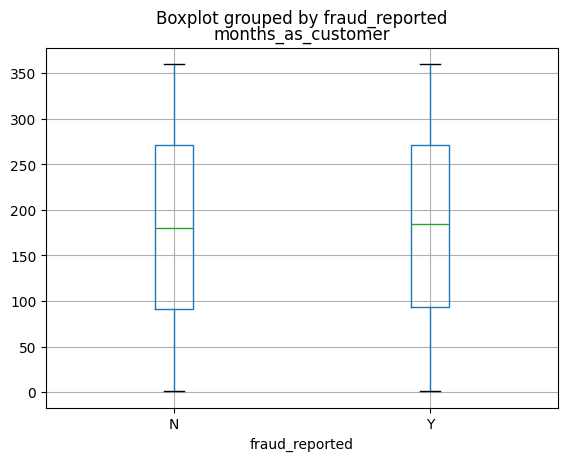

In [26]:
data.boxplot(column='months_as_customer', by='fraud_reported')

In [27]:
pd.crosstab(data['police_report_available'], data['fraud_reported'], normalize='index')

fraud_reported,N,Y
police_report_available,,
?,0.758254,0.241746
NO,0.760214,0.239786
YES,0.756313,0.243687


<Axes: >

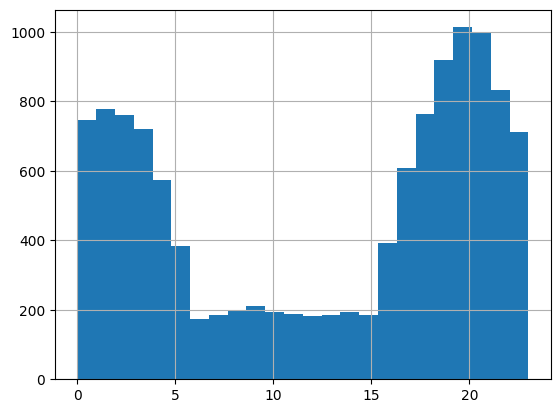

In [28]:
data.groupby('fraud_reported')['incident_hour_of_the_day'].mean()
data[data['fraud_reported']=='Y']['incident_hour_of_the_day'].hist(bins=24)

In [29]:
print(data[['total_claim_amount', 'vehicle_claim', 'injury_claim', 'property_claim']].head())
data['calculated_total'] = data['vehicle_claim'] + data['injury_claim'] + data['property_claim']
print(f"Match rate: {(data['total_claim_amount'] == data['calculated_total']).mean():.2%}")

   total_claim_amount  vehicle_claim  injury_claim  property_claim
0               16915          10672          2884            3359
1               55961          44317           284           11360
2               22055          21131             0             924
3               13539           8622          2513            2404
4               57783          36577         10918           10288
Match rate: 100.00%


In [30]:
fraud_loss = data[data['fraud_reported']=='Y']['total_claim_amount'].sum() - \
             data[data['fraud_reported']=='Y']['total_claim_amount'].mean() * 0.24  
print(f"Estimated annual fraud overpayment: ${fraud_loss:,.0f}")

Estimated annual fraud overpayment: $589,780,084


In [31]:
data['high_risk_flag'] = (
    (data['incident_severity'].isin(['Major Damage', 'Total Loss'])) & 
    (data['total_claim_amount'] > 25000)
)

In [32]:
data.replace('?',np.nan,inplace=True)

,months_as_customer,age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,capital_gains,capital_loss,credit_score,telematics_score,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,prior_claims_count,auto_make,auto_year,injury_claim,property_claim,vehicle_claim,incident_in_policy_period,policy_status_at_incident,incident_near_boundary,is_complex_claim,fraud_reported,state_mismatch,calculated_total,high_risk_flag
0,23,28,FEMALE,JD,adm-clerical,exercise,wife,PA,250/500,1000,1262.80,1000000,0,9272,496,22.1,Single Vehicle Collision,Front Collision,Total Loss,Police,PA,Residential Street,18,4,NO,1,1,NaN,16915,0,Chevrolet,2011,2884,3359,10672,N,Not Yet Effective,N,Y,N,False,16915,False
1,260,30,FEMALE,Associate,handlers-cleaners,camping,not-in-family,MA,250/500,250,1599.10,0,0,0,682,50.8,Single Vehicle Collision,Rear Collision,Minor Damage,NaN,MA,Highway,19,3,YES,3,0,YES,55961,2,Kia,2004,284,11360,44317,N,Expired,N,Y,Y,False,55961,False
2,321,59,FEMALE,Bachelors,handlers-cleaners,skydiving,not-in-family,NJ,500/1000,1000,2783.56,0,0,21182,685,98.6,Vehicle Theft,Side Collision,Trivial Damage,Fire,NJ,Interstate,18,4,NaN,0,0,YES,22055,3,Kia,2006,0,924,21131,N,Expired,N,Y,Y,False,22055,False
3,350,55,MALE,Masters,sales,yoga,husband,NC,500/1000,1000,3111.41,0,0,0,632,34.3,Vehicle Theft,Rear Collision,Major Damage,Other,NC,Interstate,9,1,NO,1,2,YES,13539,2,Hyundai,2007,2513,2404,8622,N,Expired,N,Y,N,False,13539,False
4,112,49,FEMALE,High School,craft-repair,sleeping,not-in-family,NY,500/1000,500,3782.20,100000,0,0,474,66.4,Multi-vehicle Collision,Side Collision,Minor Damage,Fire,NY,Residential Street,20,2,NaN,1,0,YES,57783,4,Jeep,2021,10918,10288,36577,N,Expired,N,Y,Y,False,57783,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,126,18,MALE,Masters,prof-specialty,video-games,own-child,WA,250/500,500,1269.27,0,0,0,776,44.8,Vehicle Theft,NaN,Trivial Damage,Fire,WA,Highway,16,3,NO,0,2,NO,4195,4,Jeep,2023,0,883,3312,N,Expired,N,Y,N,False,4195,False
49996,242,66,MALE,Associate,transport-moving,yoga,wife,NC,500/1000,2000,2131.07,1000000,0,0,551,95.1,Other,Rear Collision,Major Damage,Other,NC,Residential Street,10,2,YES,2,1,NaN,5288,0,Chevrolet,2008,867,1319,3102,N,Expired,N,Y,N,False,5288,False
49997,184,62,MALE,High School,other-service,camping,unmarried,PA,250/500,500,713.28,2000000,0,0,487,77.0,Vehicle Theft,NaN,Trivial Damage,Fire,PA,Parking Lot,17,2,NaN,0,0,NaN,65236,2,Ford,2016,0,3144,62092,N,Expired,N,Y,Y,False,65236,False
49998,245,38,FEMALE,Associate,armed-forces,paintball,husband,PA,250/500,500,1875.78,2000000,0,0,726,98.3,Single Vehicle Collision,Side Collision,Total Loss,NaN,PA,Parking Lot,15,3,YES,0,1,YES,2089,0,Kia,2006,471,150,1468,N,Expired,N,Y,N,False,2089,False


In [33]:
null_columns = [col for col in data.columns if data[col].isnull().sum()>0]

In [34]:
null_columns

['collision_type',
 'authorities_contacted',
 'property_damage',
 'police_report_available']

In [35]:
data['collision_type'] =data['collision_type'].fillna(data['collision_type'].mode()[0])
data['authorities_contacted'] = data['authorities_contacted'].fillna(data['authorities_contacted'].mode()[0])
data['property_damage'] = data['property_damage'].fillna(data['property_damage'].mode()[0])
data['police_report_available'] = data['police_report_available'].fillna(data['police_report_available'].mode()[0])

In [36]:
histplot_columns = ['policy_deductable','policy_annual_premium', 'umbrella_limit','capital-gains','capital-loss','months_as_customer','age','total_claim_amount']

In [37]:
countplot_columns = ['insured_sex','incident_type','collision_type','incident_severity','witnesses','property_damage','authorities_contacted']

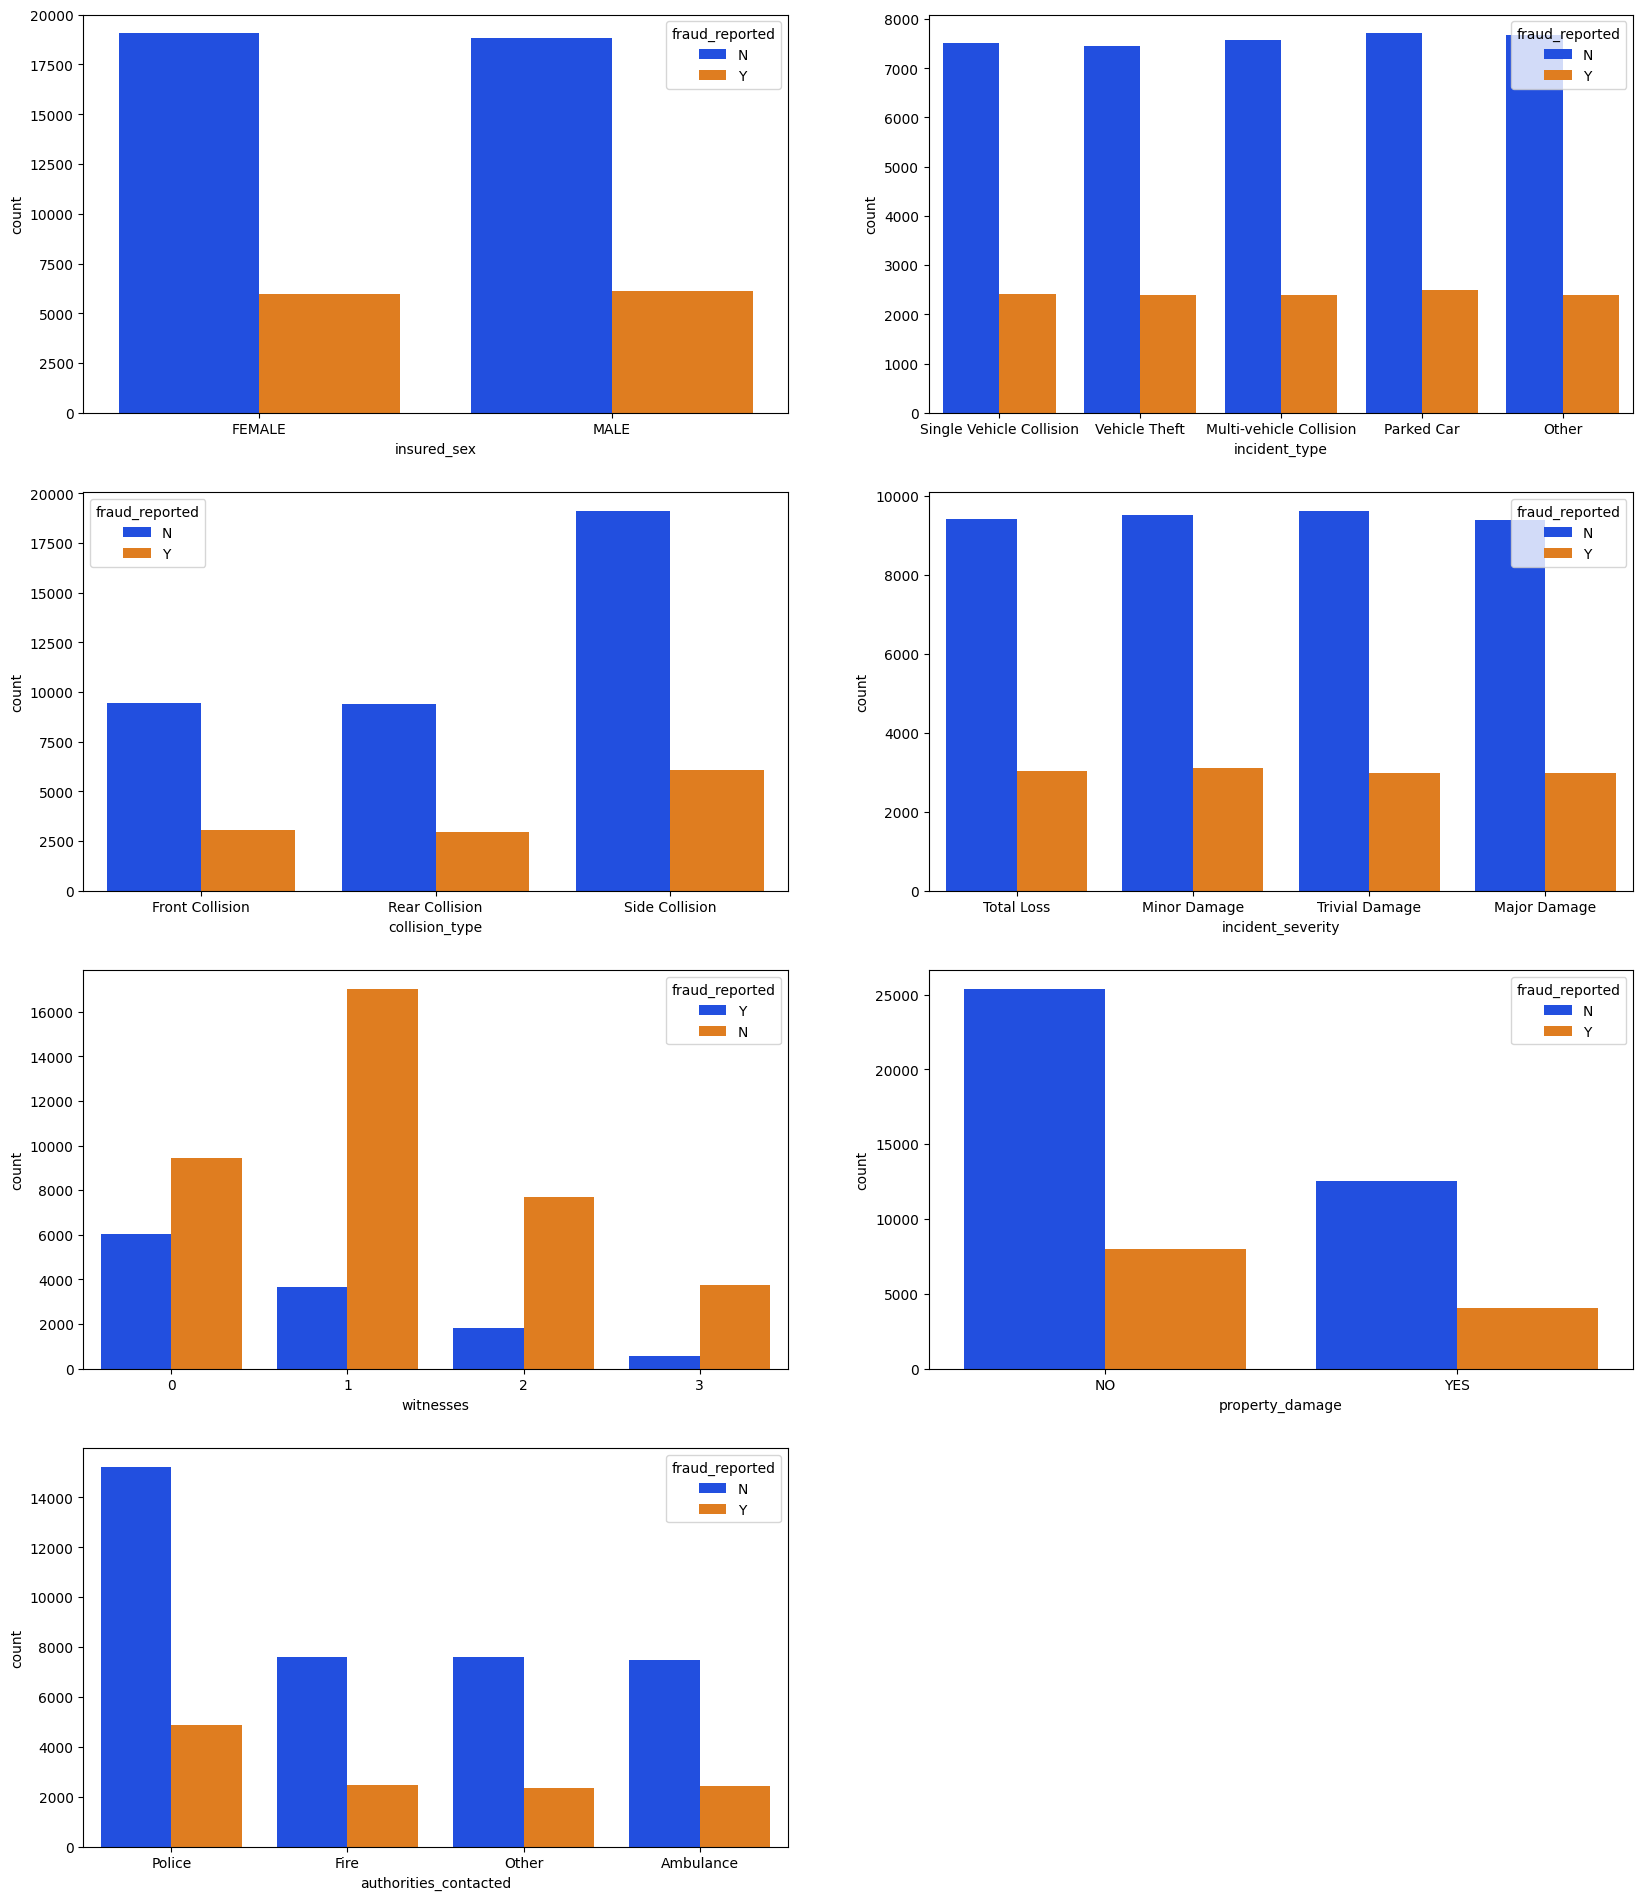

In [38]:
plt.figure(figsize=[20,30])
for i in enumerate(countplot_columns):
    plt.subplot(5,2,i[0]+1)
    sns.countplot(data=data, x =i[1],hue='fraud_reported',palette='bright')

<Axes: xlabel='insured_hobbies', ylabel='count'>

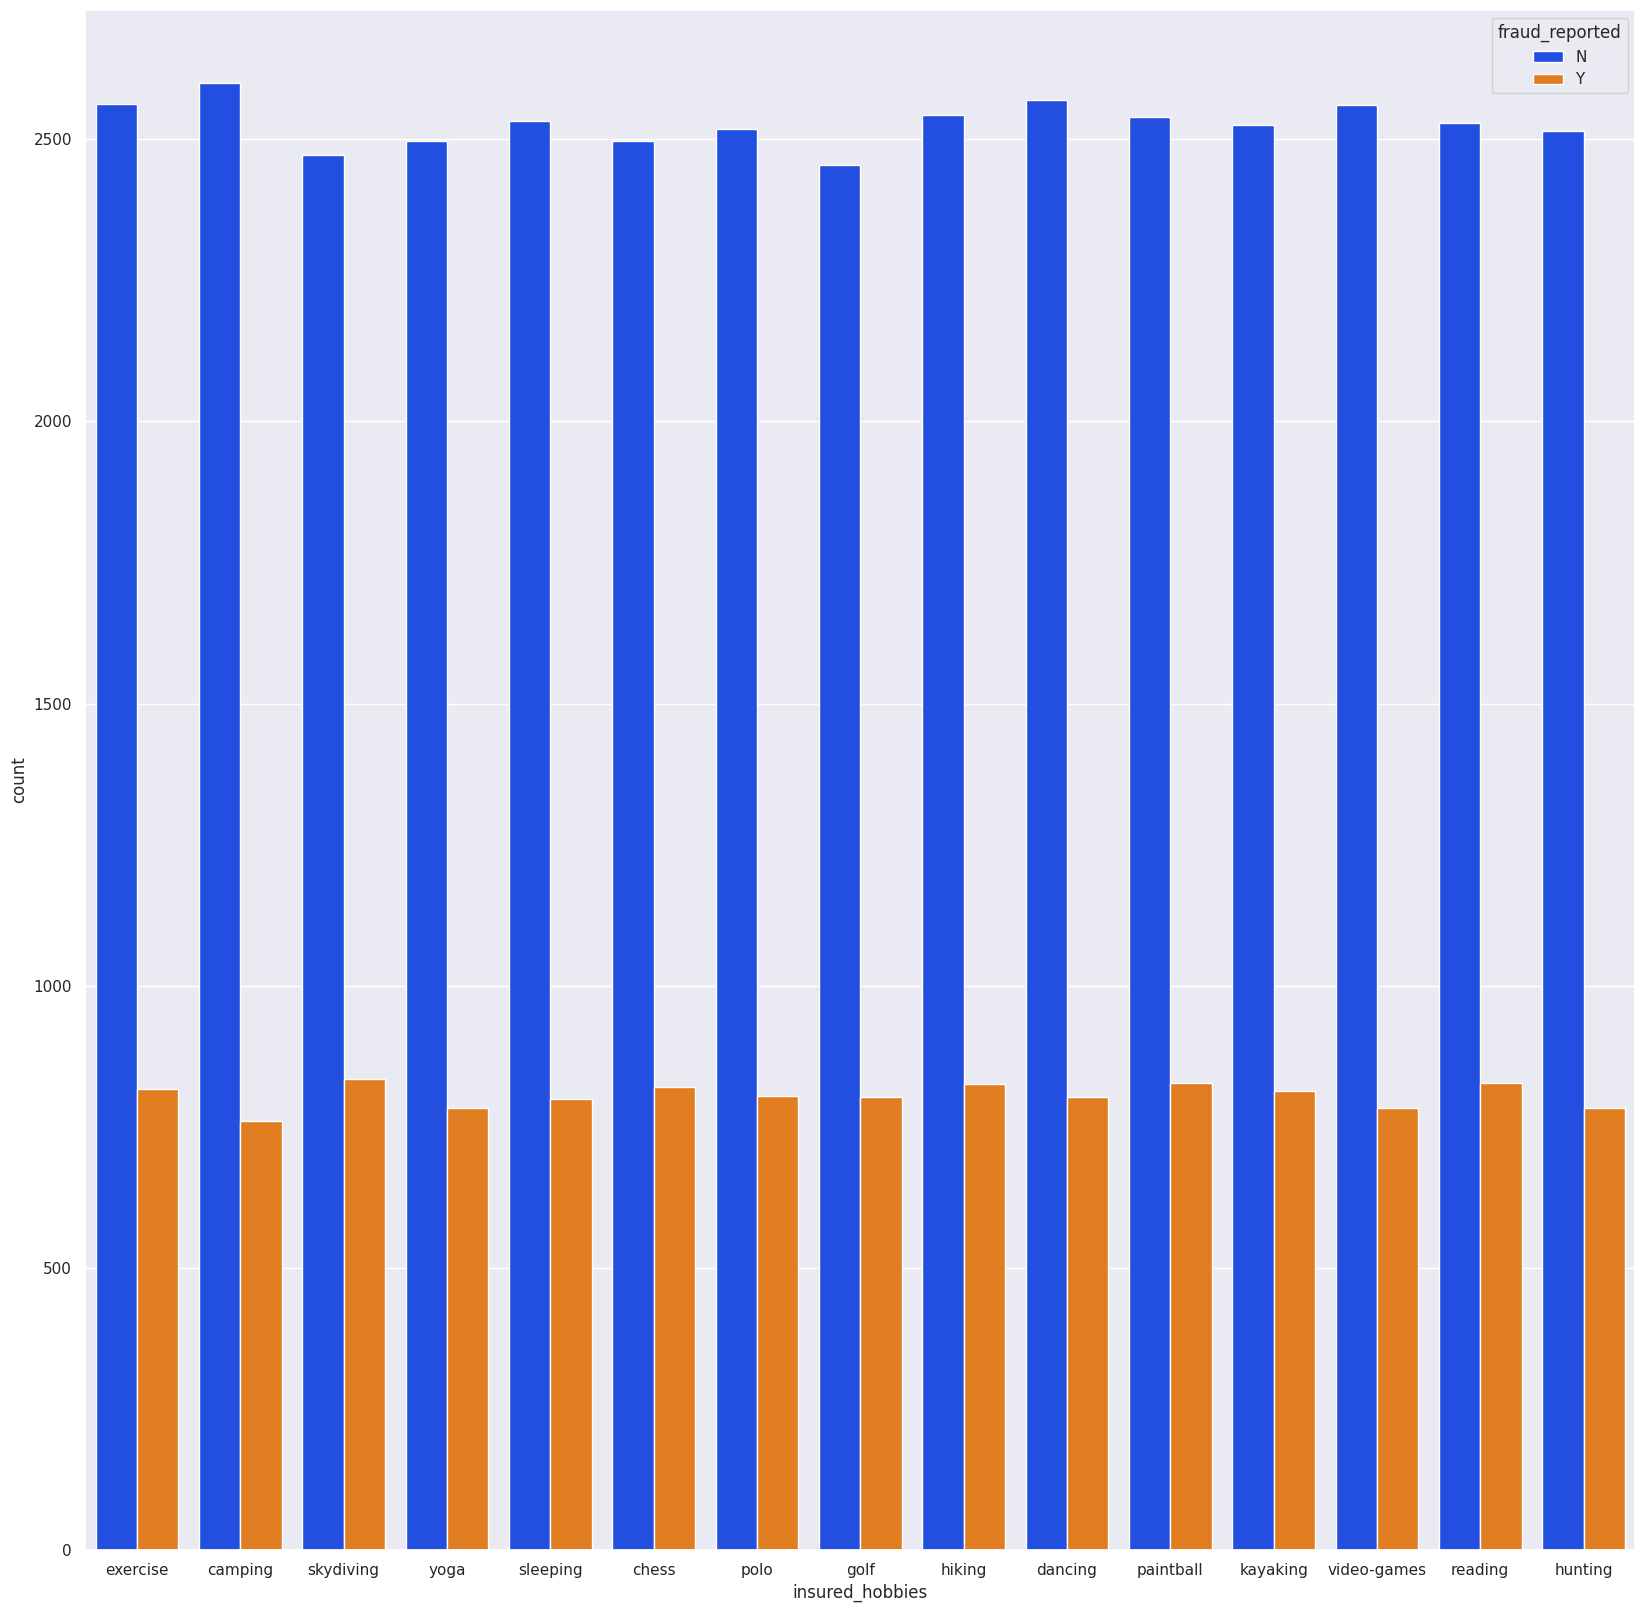

In [39]:
sns.set_theme(rc={'figure.figsize':(20,20)})
sns.countplot(x='insured_hobbies',data=data,hue='fraud_reported',palette='bright')

<Axes: xlabel='auto_model', ylabel='count'>

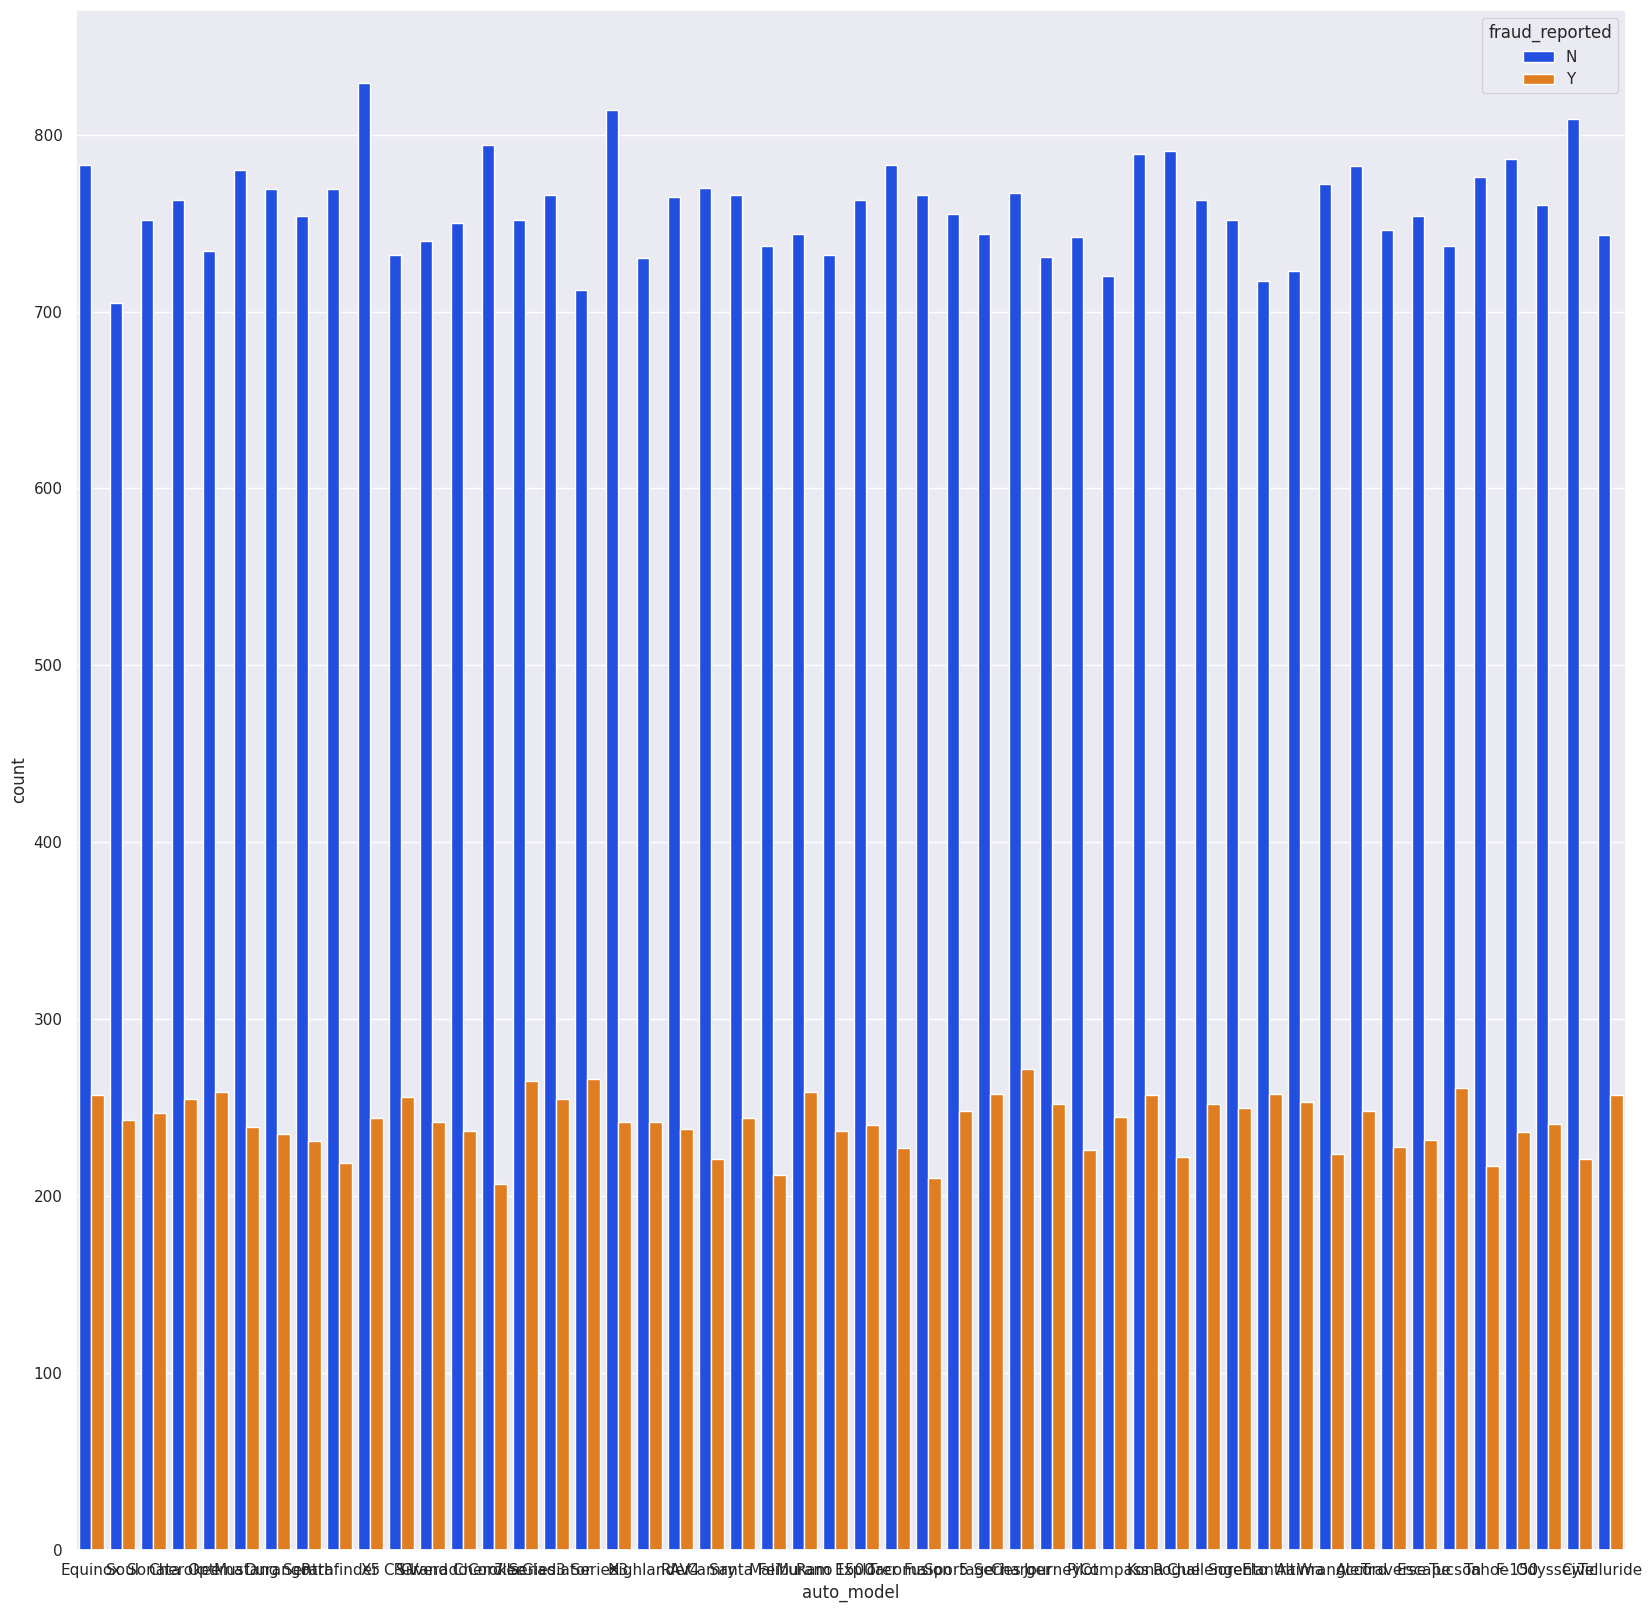

In [40]:
sns.countplot(data=df,x='auto_model',hue='fraud_reported',palette='bright')

In [41]:
col_drop = ['policy_state','policy_csl','policy_annual_premium','insured_hobbies','insured_relationship','incident_state','incident_location','injury_claim','property_claim','vehicle_claim','auto_make','auto_year']


In [42]:
data.drop(col_drop,axis = 1,inplace=True)

In [43]:
X = data.drop('fraud_reported', axis=1)
y = (data['fraud_reported'] == 'Y').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=123, 
    stratify=y
)


In [46]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import pickle
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    precision_recall_curve, average_precision_score, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import (
    GradientBoostingClassifier, RandomForestClassifier,
    AdaBoostClassifier, VotingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
import os
import tempfile
from sklearn.base import clone
# ============================================
# STEP 1: PREPARE DATA
# ============================================
X = data.drop('fraud_reported', axis=1)
y = (data['fraud_reported'] == 'Y').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# ============================================
# 3. IDENTIFY COLUMN TYPES
# ============================================
categorical_cols = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
numerical_cols   = X_train.select_dtypes(include=['number']).columns.tolist()

print(f"Numerical cols: {len(numerical_cols)}")
print(f"Categorical cols: {len(categorical_cols)}")

# ============================================
# 4. DEFINE BASE MODEL TEMPLATES
#    (cloned fresh per ensemble to avoid shared state)
# ============================================
base_model1 = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=5,
    min_samples_split=2, min_samples_leaf=1, subsample=1.0, random_state=123
)
base_model2 = RandomForestClassifier(
    n_estimators=200, max_depth=20, min_samples_split=2,
    min_samples_leaf=1, max_features='sqrt', bootstrap=True,
    random_state=123, n_jobs=-1
)
base_model3 = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=1,
    gamma=0, reg_alpha=0, reg_lambda=1, random_state=123,
    eval_metric='logloss'
)
base_model4 = LGBMClassifier(
    n_estimators=200, max_depth=10, learning_rate=0.1,
    num_leaves=31, subsample=0.8, colsample_bytree=0.8,
    min_child_samples=20, reg_alpha=0, reg_lambda=0,
    random_state=123, verbose=-1, n_jobs=-1
)
base_model5 = LogisticRegression(
    C=1.0, penalty='l2', solver='lbfgs', max_iter=1000,
    random_state=123, class_weight='balanced'
)
base_model6 = AdaBoostClassifier(
    n_estimators=200, learning_rate=1.0, random_state=123
)
base_model7 = MLPClassifier(
    hidden_layer_sizes=(100, 50), activation='relu', solver='adam',
    alpha=0.0001, batch_size='auto', learning_rate='adaptive',
    learning_rate_init=0.001, max_iter=200, random_state=123,
    early_stopping=True, validation_fraction=0.1, verbose=False
)

print("\n✅ Base model templates defined.")

# ============================================
# 5. ENSEMBLE CONFIGS
#    Each entry gets its own cloned preprocessor +
#    cloned base models so they never share state.
# ============================================
ensemble_configs = {
    'Top 4 Models (Weighted)': {
        'estimators': [
            ('gb',  base_model1), ('rf',  base_model2),
            ('xgb', base_model3), ('lgb', base_model4),
        ],
        'weights': [1.2, 0.9, 1.0, 1.1],
    },
    'All 7 Models': {
        'estimators': [
            ('gb',  base_model1), ('rf',  base_model2),
            ('xgb', base_model3), ('lgb', base_model4),
            ('lr',  base_model5), ('ada', base_model6), ('mlp', base_model7),
        ],
        'weights': [1.2, 0.9, 1.0, 1.1, 0.7, 0.8, 0.9],
    },
    'Boosting Models Only': {
        'estimators': [
            ('gb',  base_model1), ('xgb', base_model3),
            ('lgb', base_model4), ('ada', base_model6),
        ],
        'weights': [1.2, 1.0, 1.1, 0.8],
    },
    'Tree-based Models Only': {
        'estimators': [
            ('rf',  base_model2), ('gb',  base_model1),
            ('xgb', base_model3), ('lgb', base_model4),
        ],
        'weights': [0.9, 1.2, 1.0, 1.1],
    },
    'Top 4 Models (Equal)': {
        'estimators': [
            ('gb',  base_model1), ('rf',  base_model2),
            ('xgb', base_model3), ('lgb', base_model4),
        ],
        'weights': [1, 1, 1, 1],
    },
}

def make_pipeline(config):
    """Return a fresh ImbPipeline with cloned preprocessor and estimators."""
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols),
        ]
    )
    ensemble = VotingClassifier(
        estimators=[(name, clone(est)) for name, est in config['estimators']],
        voting='soft',
        weights=config['weights'],
    )
    return ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote',        SMOTE(random_state=123)),
        ('classifier',   ensemble),
    ])

print("✅ Pipeline factory ready (fresh clones per ensemble).")

# ============================================
# 6. TRAIN AND EVALUATE ALL ENSEMBLES
# ============================================
results_ensembles = []
trained_pipelines = {}

for name, config in ensemble_configs.items():
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")
    try:
        pipeline = make_pipeline(config)
        pipeline.fit(X_train, y_train)

        y_pred  = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]

        auc       = roc_auc_score(y_test, y_proba)
        f1        = f1_score(y_test, y_pred)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0

        results_ensembles.append({
            'Ensemble':          name,
            'AUC-ROC':           auc,
            'F1-Score':          f1,
            'Fraud Recall (TPR)': recall,
            'Precision':         precision,
            'Fraud Caught':      tp,
            'False Alarms':      fp,
            'Fraud Missed':      fn,
        })
        trained_pipelines[name] = pipeline
        print(f"✅ AUC-ROC: {auc:.4f} | Recall: {recall:.2%} | Precision: {precision:.2%} | F1: {f1:.4f}")
    except Exception as e:
        print(f"❌ Error training '{name}': {e}")

# ============================================
# 7. SELECT BEST ENSEMBLE (by AUC-ROC)
# ============================================
results_df = pd.DataFrame(results_ensembles).sort_values('AUC-ROC', ascending=False)

print("\n" + "="*80)
print("ENSEMBLE PERFORMANCE COMPARISON")
print("="*80)
print(results_df[['Ensemble', 'AUC-ROC', 'Fraud Recall (TPR)', 'Precision', 'F1-Score']].to_string(index=False))

best_name     = results_df.iloc[0]['Ensemble']
best_pipeline = trained_pipelines[best_name]

print(f"\n🏆 BEST ENSEMBLE: {best_name}")
print(f"   AUC-ROC: {results_df.iloc[0]['AUC-ROC']:.4f}")
print(f"   Fraud Detection Rate: {results_df.iloc[0]['Fraud Recall (TPR)']:.2%}")

# ============================================
# 8. THRESHOLD TUNING
#    The default 0.5 threshold often under-recalls in fraud.
#    We sweep thresholds and pick the one that maximises F1
#    (swap 'f1' for 'recall' if catching all fraud is the priority).
# ============================================
print("\n" + "="*80)
print("THRESHOLD TUNING")
print("="*80)

y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)

# F1 for every threshold
f1_scores = np.where(
    (precisions[:-1] + recalls[:-1]) > 0,
    2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1]),
    0,
)
best_thresh_idx   = np.argmax(f1_scores)
best_threshold    = thresholds[best_thresh_idx]
best_thresh_f1    = f1_scores[best_thresh_idx]
best_thresh_prec  = precisions[best_thresh_idx]
best_thresh_rec   = recalls[best_thresh_idx]

print(f"\nOptimal threshold (max F1): {best_threshold:.4f}")
print(f"  Recall:    {best_thresh_rec:.2%}")
print(f"  Precision: {best_thresh_prec:.2%}")
print(f"  F1-Score:  {best_thresh_f1:.4f}")

# Apply tuned threshold
y_pred_tuned = (y_proba_best >= best_threshold).astype(int)
tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_tuned).ravel()

print(f"\n  Fraud caught:  {tp_t} / {tp_t + fn_t}")
print(f"  False alarms:  {fp_t}")
print(f"  Fraud missed:  {fn_t}")

# ============================================
# 9. SAVE BEST PIPELINE + THRESHOLD
# ============================================
model_filename = 'best_ensemble_fraud_model.pkl'
save_payload   = {'pipeline': best_pipeline, 'threshold': best_threshold}
save_success   = False
saved_path     = None

try:
    abs_path   = os.path.abspath(model_filename)
    parent_dir = os.path.dirname(abs_path) or '.'   # FIX: never pass empty string
    os.makedirs(parent_dir, exist_ok=True)
    joblib.dump(save_payload, abs_path)
    saved_path   = abs_path
    save_success = True
    print(f"\n✅ Model + threshold saved → '{abs_path}'")
except Exception as e1:
    print(f"\n⚠️  Could not save to '{model_filename}': {e1}")
    try:
        with tempfile.NamedTemporaryFile(delete=False, suffix='.pkl') as tmp:
            joblib.dump(save_payload, tmp.name)
            saved_path   = tmp.name
            save_success = True
            print(f"✅ Saved to temporary location: {tmp.name}")
    except Exception as e2:
        print(f"❌ Temporary save also failed: {e2}")

# ============================================
# 10. VERIFY LOADED MODEL
# ============================================
if save_success and saved_path and os.path.exists(saved_path):
    try:
        loaded        = joblib.load(saved_path)
        loaded_pipe   = loaded['pipeline']
        loaded_thresh = loaded['threshold']

        y_proba_check = loaded_pipe.predict_proba(X_test)[:, 1]
        y_pred_check  = (y_proba_check >= loaded_thresh).astype(int)
        auc_check     = roc_auc_score(y_test, y_proba_check)
        f1_check      = f1_score(y_test, y_pred_check)

        print(f"\n✅ Model verified after reload — AUC: {auc_check:.4f} | F1: {f1_check:.4f} | Threshold: {loaded_thresh:.4f}")
    except Exception as e:
        print(f"\n⚠️  Could not verify loaded model: {e}")
else:
    print("\n⚠️  Skipping verification — model was not saved.")

# ============================================
# 11. BUSINESS IMPACT ANALYSIS
# ============================================
total_fraud_loss = 590_000_000

print("\n" + "="*80)
print("BUSINESS IMPACT ANALYSIS")
print("="*80)

# Default threshold (0.5)
y_pred_default         = best_pipeline.predict(X_test)
tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_test, y_pred_default).ravel()
recall_default         = tp_d / (tp_d + fn_d) if (tp_d + fn_d) > 0 else 0

# Tuned threshold
recall_tuned = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0

print(f"\nBest ensemble: {best_name}")
print(f"\n  ── Default threshold (0.50) ──────────────────────────")
print(f"     Fraud caught:      {tp_d} / {tp_d + fn_d}  ({recall_default:.2%})")
print(f"     False alarms:      {fp_d}")
print(f"     Recovery:          ${total_fraud_loss * recall_default:,.0f}")
print(f"     Remaining loss:    ${total_fraud_loss * (1 - recall_default):,.0f}")

print(f"\n  ── Tuned threshold  ({best_threshold:.4f}) ──────────────────────")
print(f"     Fraud caught:      {tp_t} / {tp_t + fn_t}  ({recall_tuned:.2%})")
print(f"     False alarms:      {fp_t}")
print(f"     Recovery:          ${total_fraud_loss * recall_tuned:,.0f}")
print(f"     Remaining loss:    ${total_fraud_loss * (1 - recall_tuned):,.0f}")

print(f"\n  ── Uplift from threshold tuning ──────────────────────")
print(f"     Extra fraud caught:  {tp_t - tp_d}")
print(f"     Extra $ recovered:   ${total_fraud_loss * (recall_tuned - recall_default):,.0f}")

# ============================================
# 12. INFERENCE HELPER
# ============================================
def predict_fraud(X_new: pd.DataFrame,
                  pipeline,
                  threshold: float = 0.5) -> pd.DataFrame:
    """
    Run inference on new data.

    Parameters
    ----------
    X_new      : DataFrame with the same columns used at training time.
    pipeline   : Fitted ImbPipeline (preprocessor + SMOTE + classifier).
    threshold  : Decision threshold (default 0.5; use tuned value for better recall).

    Returns
    -------
    DataFrame with columns: fraud_probability, fraud_flag
    """
    proba = pipeline.predict_proba(X_new)[:, 1]
    flags = (proba >= threshold).astype(int)
    return pd.DataFrame({'fraud_probability': proba, 'fraud_flag': flags}, index=X_new.index)


sample_results = predict_fraud(X_test.head(10), best_pipeline, threshold=best_threshold)
print("\n" + "="*80)
print("SAMPLE INFERENCE (first 10 test rows)")
print("="*80)
print(sample_results.to_string())

print("\n✅ All done — pipeline ready for production.")

Train size: 35000, Test size: 15000
Numerical cols: 15
Categorical cols: 13

✅ Base model templates defined.
✅ Pipeline factory ready (fresh clones per ensemble).

Training: Top 4 Models (Weighted)


/home/lang-chain/Documents/mcp_insurance/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/lang-chain/Documents/mcp_insurance/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ AUC-ROC: 0.9838 | Recall: 86.29% | Precision: 94.99% | F1: 0.9043

Training: All 7 Models


/home/lang-chain/Documents/mcp_insurance/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/lang-chain/Documents/mcp_insurance/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/lang-chain/Documents/mcp_insurance/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ AUC-ROC: 0.9818 | Recall: 86.27% | Precision: 95.05% | F1: 0.9044

Training: Boosting Models Only


...


Optimal threshold (max F1): 0.4772
  Recall:    87.31%
  Precision: 93.92%
  F1-Score:  0.9050

  Fraud caught:  3166 / 3626
  False alarms:  205
  Fraud missed:  460

✅ Model + threshold saved → '/home/lang-chain/Documents/mcp_insurance/notebook/best_ensemble_fraud_model.pkl'


/home/lang-chain/Documents/mcp_insurance/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



✅ Model verified after reload — AUC: 0.9840 | F1: 0.9050 | Threshold: 0.4772

BUSINESS IMPACT ANALYSIS


/home/lang-chain/Documents/mcp_insurance/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/lang-chain/Documents/mcp_insurance/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Best ensemble: Boosting Models Only

  ── Default threshold (0.50) ──────────────────────────
     Fraud caught:      3144 / 3626  (86.71%)
     False alarms:      183
     Recovery:          $511,571,980
     Remaining loss:    $78,428,020

  ── Tuned threshold  (0.4772) ──────────────────────
     Fraud caught:      3166 / 3626  (87.31%)
     False alarms:      205
     Recovery:          $515,151,682
     Remaining loss:    $74,848,318

  ── Uplift from threshold tuning ──────────────────────
     Extra fraud caught:  22
     Extra $ recovered:   $3,579,702

SAMPLE INFERENCE (first 10 test rows)
       fraud_probability  fraud_flag
33024           0.938257           1
41169           0.131864           0
46596           0.260201           0
48097           0.179357           0
20689           0.056105           0
1257            0.937106           1
41816           0.091370           0
42961           0.313874           0
13190           0.102316           0
31585           0.09857